In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipcodes as zcode

In [3]:
df = pd.read_csv('../data/Bank_Personal_Loan_Modelling(1).csv')
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  5000 non-null   int64
 1   Age                 5000 non-null   int64
 2   Experience          5000 non-null   int64
 3   Income              5000 non-null   int64
 4   ZIP Code            5000 non-null   int64
 5   Family              5000 non-null   int64
 6   CCAvg               5000 non-null   str  
 7   Education           5000 non-null   int64
 8   Mortgage            5000 non-null   int64
 9   Personal Loan       5000 non-null   int64
 10  Securities Account  5000 non-null   int64
 11  CD Account          5000 non-null   int64
 12  Online              5000 non-null   int64
 13  CreditCard          5000 non-null   int64
dtypes: int64(13), str(1)
memory usage: 547.0 KB
None
ID                    0
Age                   0
Experience            0
Income                0
ZI

In [5]:
df['CCAvg'] = df['CCAvg'].astype(str).str.replace('/', '.').astype(float)

In [6]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [7]:
## all feacure is /year so we convert CCAvg to /year

In [8]:
df['CCAvg'] = df['CCAvg']*12

In [9]:
df['Experience'] = abs(df['Experience'])

In [10]:
## id has no effect on target
df.drop(columns=['ID'], inplace=True)

In [11]:
df['ZIP Code'].nunique()

467

noise

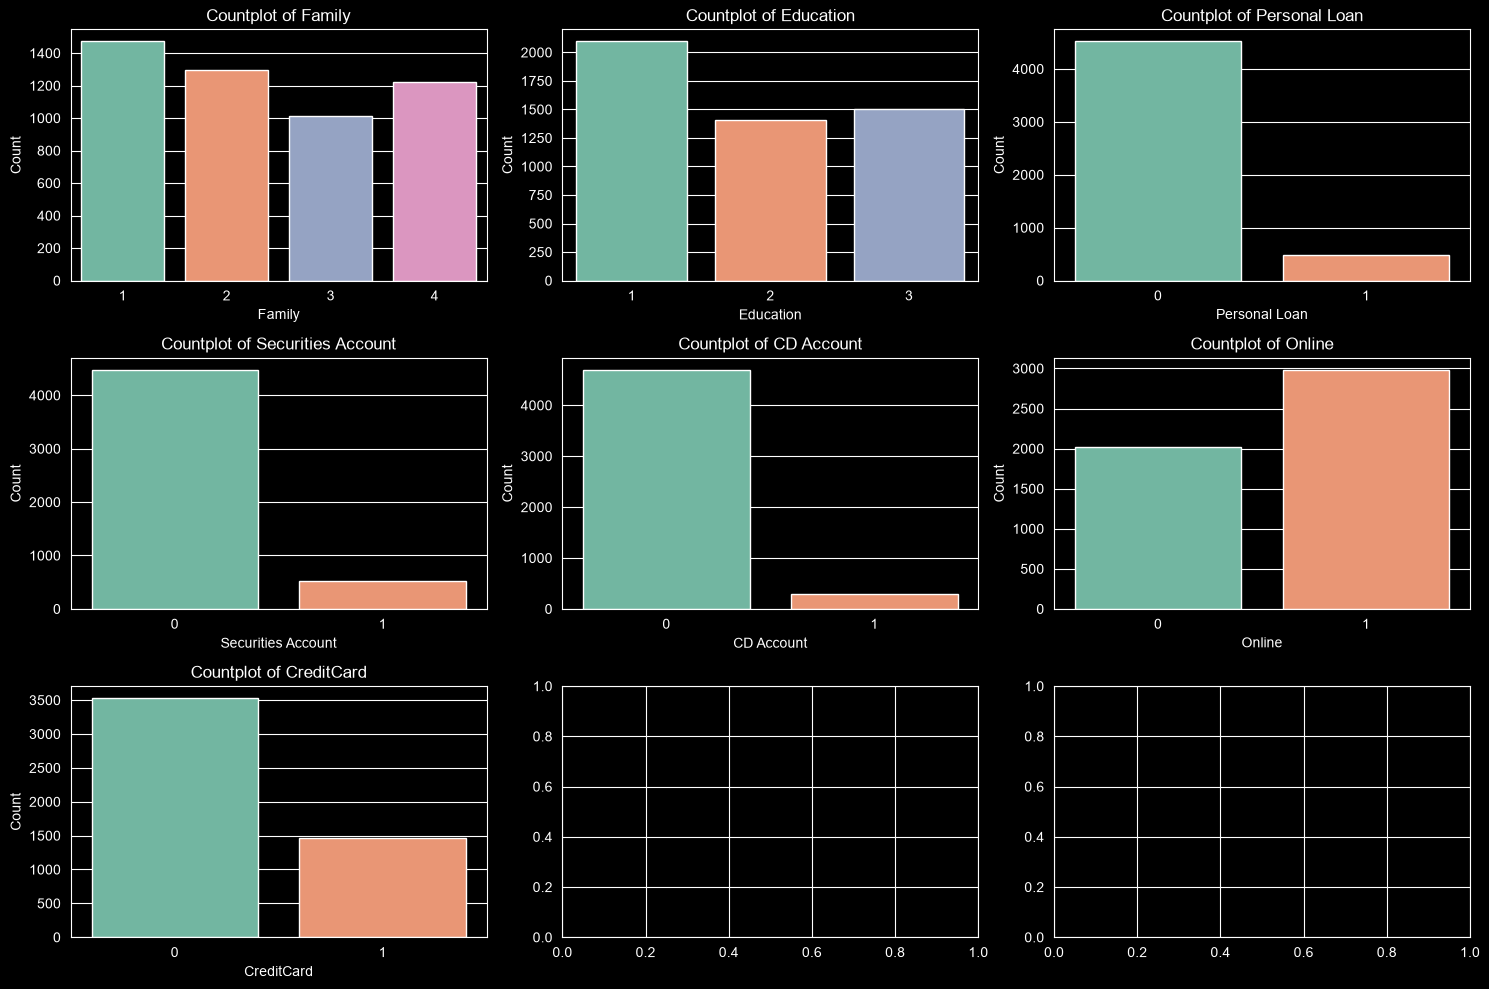

In [12]:
##categorical
categorical_cols = ['Family', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

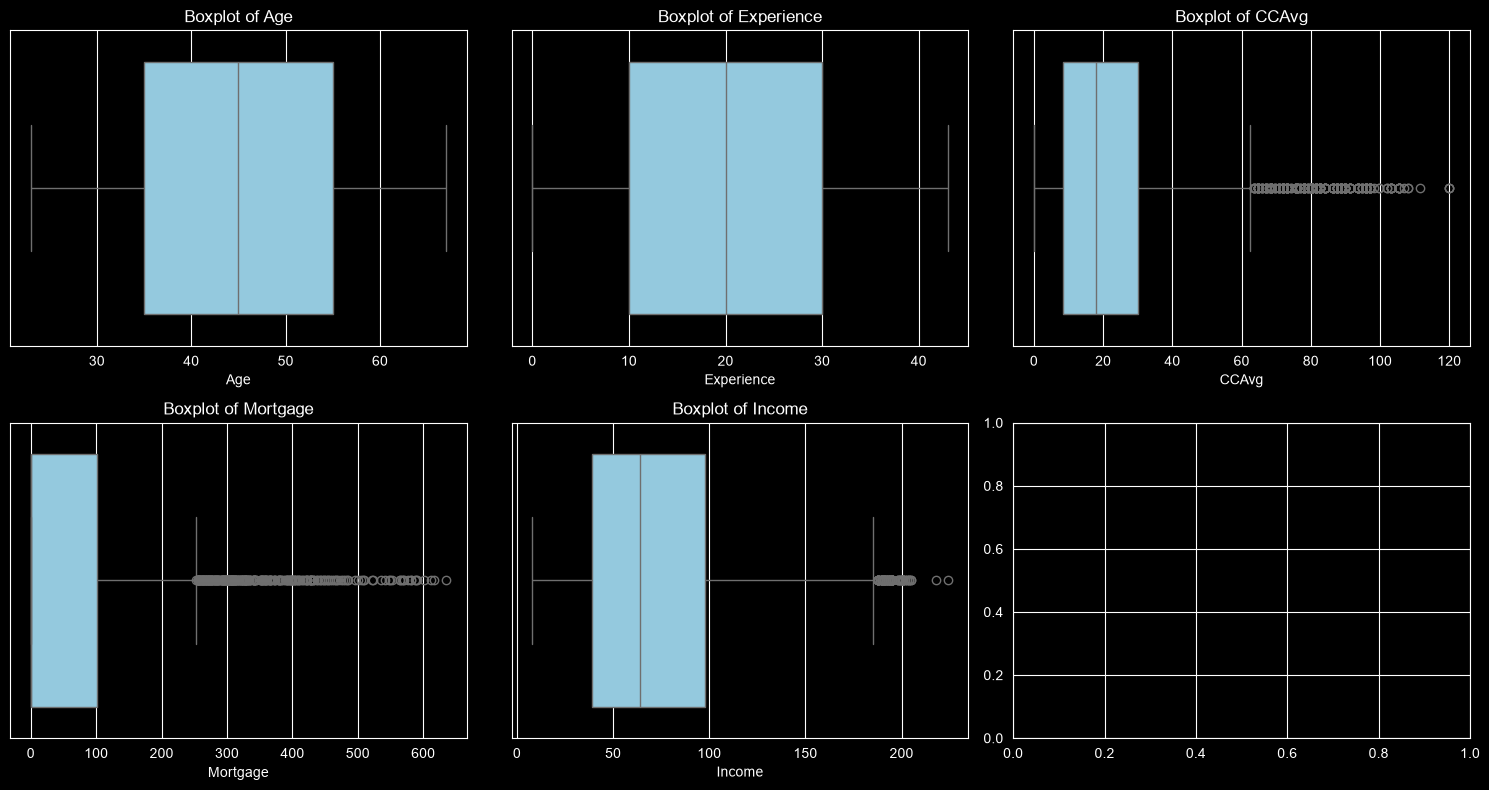

In [13]:
##numerical
numerical_cols = ['Age', 'Experience', 'CCAvg', 'Mortgage', 'Income']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

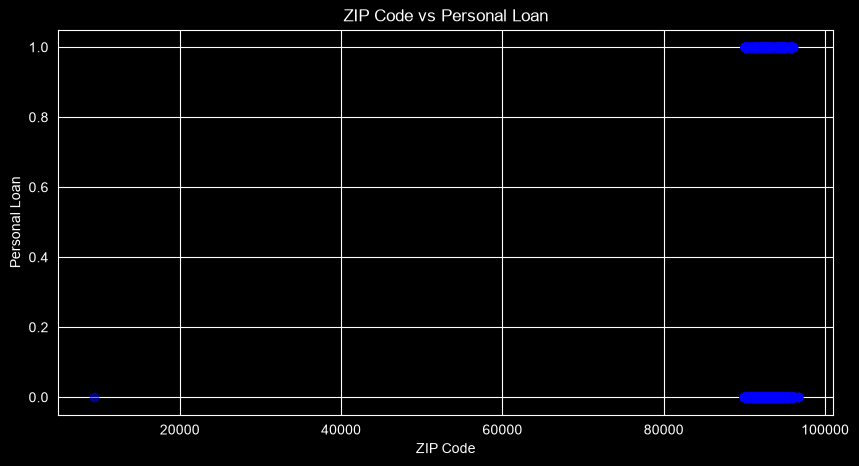

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(df['ZIP Code'], df['Personal Loan'], alpha=0.5, color='blue')
plt.title('ZIP Code vs Personal Loan')
plt.xlabel('ZIP Code')
plt.ylabel('Personal Loan')
plt.grid(True)
plt.show()

In [15]:
zip_noise = df[df['ZIP Code']<80000]
zip_noise

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
384,51,25,21,9307,4,7.2,3,0,0,0,0,1,1


In [16]:
df.drop(index=zip_noise.index, inplace=True)

In [17]:
unique_zips = df['ZIP Code'].unique()

place_map = {}
lat_map = {}
long_map = {}

for z in unique_zips:
    my_city_county = zcode.matching(str(z))
    if len(my_city_county) == 1:
        place_map[z] = my_city_county[0].get('county')
        lat_map[z] = my_city_county[0].get('lat')
        long_map[z] = my_city_county[0].get('long')
    else:
        place_map[z] = "Notfound"
        lat_map[z] = np.nan
        long_map[z] = np.nan

df["Place"] = df['ZIP Code'].map(place_map)
df["Latitude"] = df['ZIP Code'].map(lat_map)
df["Longitude"] = df['ZIP Code'].map(long_map)

In [18]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Place,Latitude,Longitude
0,25,1,49,91107,4,19.2,1,0,0,1,0,0,0,Los Angeles County,34.151,-118.0889
1,45,19,34,90089,3,18.0,1,0,0,1,0,0,0,Los Angeles County,33.7866,-118.2987
2,39,15,11,94720,1,12.0,1,0,0,0,0,0,0,Alameda County,37.8738,-122.2549
3,35,9,100,94112,1,32.4,2,0,0,0,0,0,0,San Francisco County,37.7195,-122.4411
4,35,8,45,91330,4,12.0,2,0,0,0,0,0,1,Los Angeles County,34.2283,-118.5368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,22.8,3,0,0,0,0,1,0,Orange County,33.6485,-117.8387
4996,30,4,15,92037,4,4.8,1,85,0,0,0,1,0,San Diego County,32.8455,-117.2521
4997,63,39,24,93023,2,3.6,3,0,0,0,0,0,0,Ventura County,34.4451,-119.2565
4998,65,40,49,90034,3,6.0,2,0,0,0,0,1,0,Los Angeles County,34.029,-118.4005


In [19]:
df.describe(include='all')

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Place,Latitude,Longitude
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999,4966,4966
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,447,446
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Los Angeles County,37.8738,-122.2549
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1095,169,169
mean,45.337267,20.133627,73.784757,93169.275455,2.396079,23.258468,1.880776,56.510102,0.096019,0.104421,0.060412,0.596719,0.293859,NaN,NaN,NaN
std,11.464033,11.416124,46.032281,1759.630610,1.147554,20.972776,0.839804,101.720837,0.294647,0.305836,0.238273,0.490605,0.455574,NaN,NaN,NaN
min,23.000000,0.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,8.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,18.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,30.000000,3.000000,101.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN


In [20]:
# now we have missing vlue

In [21]:
df[df['Place'] == "Notfound"]['ZIP Code'].value_counts()

ZIP Code
92717    22
96651     6
92634     5
Name: count, dtype: int64

In [24]:
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['Place'] = df['Place'].astype(str)

manual_updates = {
    92717: {'Place': 'Irvien', 'Latitude': 33.6462, 'Longitude': -117.8398},
    92634: {'Place': 'Fullerton', 'Latitude': 33.8739, 'Longitude': -117.9028},
    96651: {'Place': 'Rudno nad Hronom', 'Latitude': 48.4242, 'Longitude': 18.7071}
}

for zip_code, info in manual_updates.items():
    mask = df['ZIP Code'] == zip_code

    df.loc[mask, 'Place'] = str(info['Place'])
    df.loc[mask, 'Latitude'] = float(info['Latitude'])
    df.loc[mask, 'Longitude'] = float(info['Longitude'])

In [27]:
import plotly.express as px

df['Loan_Status'] = df['Personal Loan'].map({0: 'No Loan (0)', 1: 'Loan Accepted (1)'})

fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Loan_Status",
    color_discrete_map={
        'No Loan (0)': '#1f77b4',
        'Loan Accepted (1)': '#ff7f0e'
    },
    hover_name="Place",
    zoom=5,
    height=600,
)

fig.update_layout(map_style="open-street-map")
fig.show()

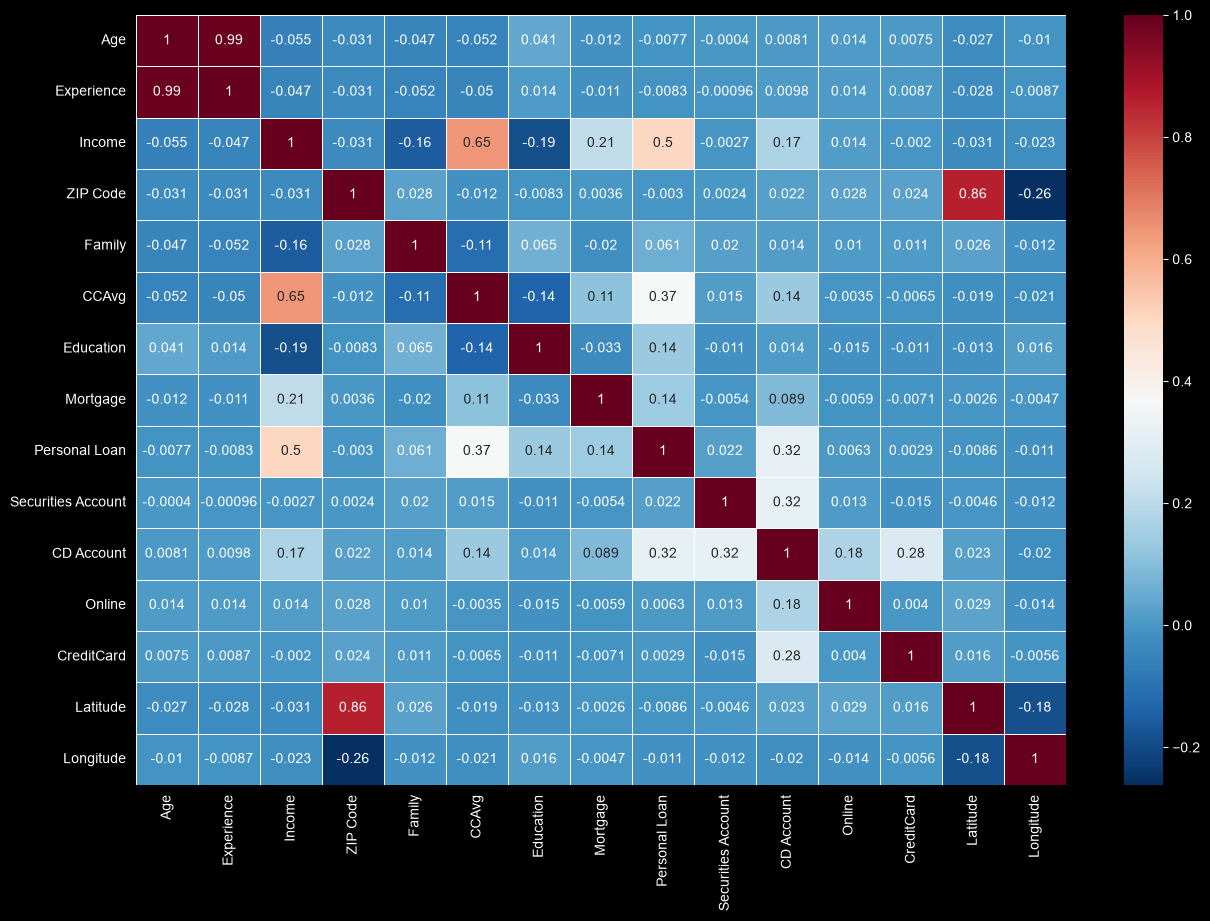

In [29]:
fig, ax = plt.subplots(figsize = (15, 10)) #Size of plot
sns.heatmap(df.corr(numeric_only=True), cmap='RdBu_r', cbar=True, annot=True, linewidths=0.5, ax=ax)
plt.show()

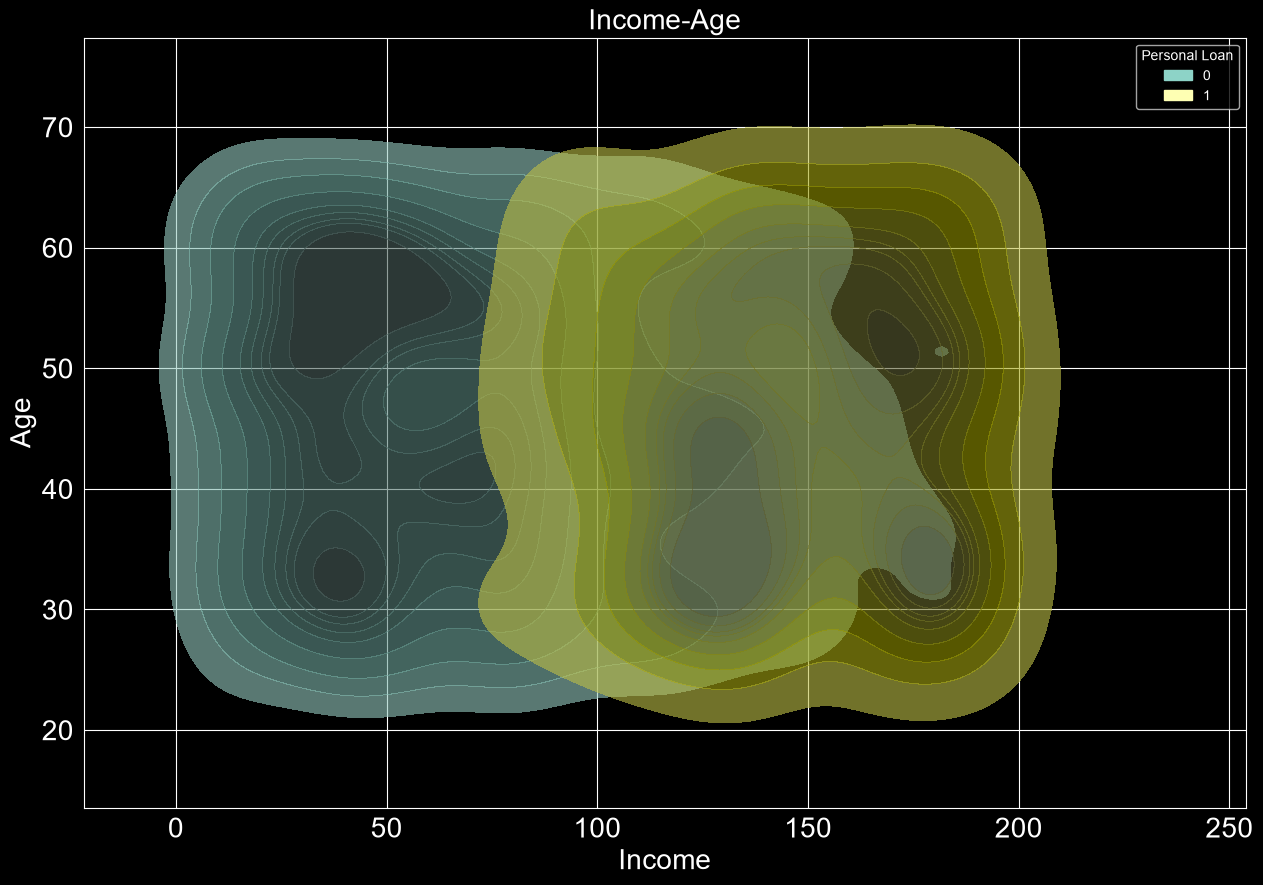

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

sns.kdeplot(
    data=df,
    x='Income',
    y='Age',
    hue="Personal Loan",
    fill=True,
    common_norm=False,
    palette={0: "blue", 1: "red"},
    alpha=0.6,
    thresh=0.05
)

plt.title("Income-Age", fontsize=20)
plt.xlabel("Income", fontsize=20)
plt.ylabel("Age", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.show()

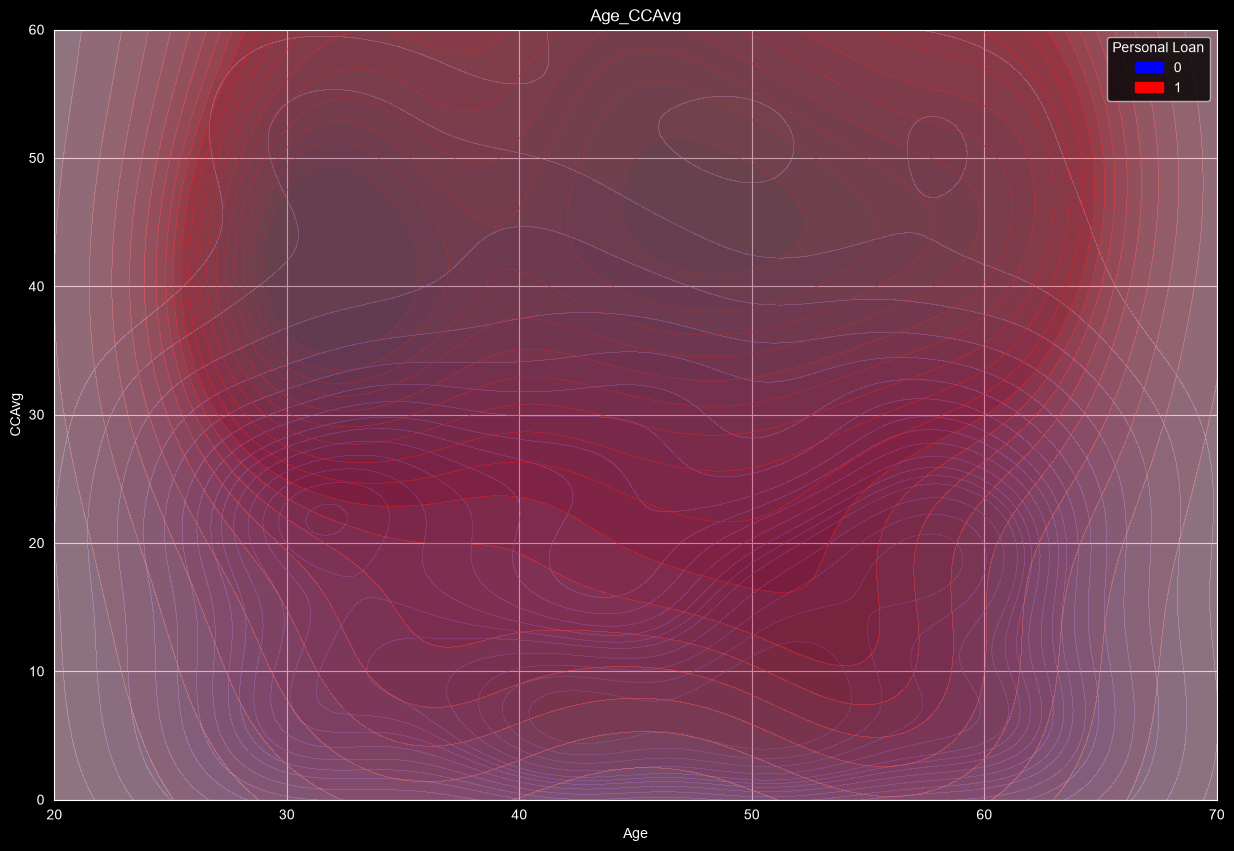

In [63]:
plt.figure(figsize=(15,10))

sns.kdeplot(
    data=df,
    x="Age",
    y="CCAvg",
    hue="Personal Loan",
    fill=True,
    common_norm=False,
    levels=20,
    palette={0: "blue", 1: "red"},
    thresh=0,
    alpha=0.4
)

plt.xlim(20,70)
plt.ylim(0,60)

plt.title("Age_CCAvg")
plt.show()